# CAZ Implementation Demo

*From formulas to Paper 4: implement the metrics and reproduce the cross-architecture convergence result*

This notebook works through the mathematics behind the CAZ framework:

1. **The three metrics** — Fisher separation, coherence, and velocity, implemented from first principles and verified against stored results
2. **Procrustes alignment** — the rotation that maps concept directions across architectures, implemented and demonstrated on real data
3. **The PRH result** — a live re-run of the Paper 4 analysis using pre-computed CAZ results downloaded from Hugging Face, reproducing the matched vs. mismatched cosine distribution

No model loading or GPU required. All data comes from the [Rosetta Activations](https://huggingface.co/datasets/james-ra-henry/Rosetta-Activations) dataset.

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a, 2026d)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("huggingface_hub", "matplotlib", "numpy", "scipy", "pandas")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from scipy.stats import mannwhitneyu
from huggingface_hub import hf_hub_download
from pathlib import Path

HF_REPO = "james-ra-henry/Rosetta-Activations"
# Paper data (N=250, frozen at paper-n250 tag). Switch to "models" when full RCP is available.
HF_DATA_ROOT = "paper_n250"
print("Imports ready.")

Imports ready.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


## 1. Fisher separation

$S(l)$ measures how separable the two class representations are at layer $l$.

$$S(l) = \frac{\|\mu_+ - \mu_-\|}{\sqrt{\frac{1}{2}(\sigma_+^2 + \sigma_-^2)}}$$

$\mu_+, \mu_-$ are the class centroids; $\sigma_+^2, \sigma_-^2$ are within-class variances projected onto the concept direction $\hat{d} = (\mu_+ - \mu_-)/\|\mu_+ - \mu_-\|$. This is the Fisher discriminant ratio — a natural measure that normalises for within-class scatter.

In [4]:
def separation(pos: np.ndarray, neg: np.ndarray) -> float:
    mu_p, mu_n = pos.mean(0), neg.mean(0)
    diff = mu_p - mu_n
    norm = np.linalg.norm(diff)
    if norm < 1e-12:
        return 0.0
    d_hat = diff / norm
    var_p = ((pos @ d_hat) - (pos @ d_hat).mean()) ** 2
    var_n = ((neg @ d_hat) - (neg @ d_hat).mean()) ** 2
    within = np.sqrt(0.5 * (var_p.mean() + var_n.mean()))
    return float(norm / within) if within > 1e-12 else float(norm)

# Sanity check
rng = np.random.default_rng(42)
pos_sep = rng.normal([2, 0], 0.4, (30, 2))
neg_sep = rng.normal([0, 0], 0.4, (30, 2))
pos_mix = rng.normal([0, 0], 1.5, (30, 2))
neg_mix = rng.normal([0, 0], 1.5, (30, 2))
print(f"Separation (well-separated classes):  {separation(pos_sep, neg_sep):.3f}")
print(f"Separation (overlapping classes):     {separation(pos_mix, neg_mix):.3f}")

Separation (well-separated classes):  6.537
Separation (overlapping classes):     0.284


## 2. Coherence

$C(l)$ measures how geometrically organised each class is — whether positive examples all point in a consistent direction, not just that the centroids are far apart.

$$C(l) = \frac{1}{2}\left(\frac{1}{n_+}\sum_i \frac{x_i^+ \cdot \mu_+}{\|x_i^+\| \|\mu_+\|} + \frac{1}{n_-}\sum_j \frac{x_j^- \cdot \mu_-}{\|x_j^-\| \|\mu_-\|}\right)$$

A high-separation, low-coherence layer is a diffuse separation — the centroids are far apart but individual examples are scattered. A CAZ peak typically has both high $S$ and high $C$.

In [5]:
def coherence(pos: np.ndarray, neg: np.ndarray) -> float:
    def _class_coh(acts: np.ndarray) -> float:
        centroid = acts.mean(0)
        c_norm = np.linalg.norm(centroid)
        if c_norm < 1e-12:
            return 0.0
        norms = np.linalg.norm(acts, axis=1, keepdims=True).clip(min=1e-12)
        return float(((acts / norms) @ (centroid / c_norm)).mean())
    return 0.5 * (_class_coh(pos) + _class_coh(neg))

## 3. Velocity — and verifying against stored results

$v(l)$ is the layer-wise derivative of $S(l)$: the rate at which separation is changing. It peaks *before* the separation peak, marking the onset of rapid concept construction.

$$v(l) \approx \frac{S(l + w/2) - S(l - w/2)}{w}$$

The stored CAZ JSON contains pre-computed values for all three metrics. We verify our velocity implementation by comparing it to the stored values.

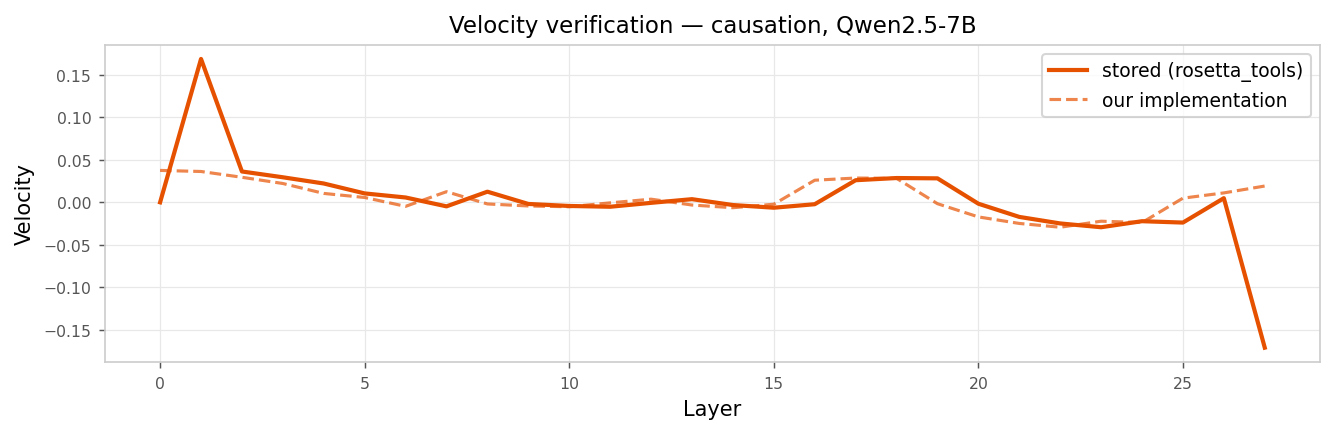

Max absolute difference: 1.90e-01
Note: rosetta_tools uses smoothed np.diff; this is a sliding-window approximation.


In [6]:
def velocity(separations: list, window: int = 3) -> list:
    s = np.array(separations, float)
    pad = window // 2
    # Asymmetric pad: right side gets (window - pad) so s_pad[i+window] stays in bounds
    s_pad = np.pad(s, (pad, window - pad), mode="edge")
    return [(s_pad[i + window] - s_pad[i]) / window for i in range(len(s))]

path = hf_hub_download(
    HF_REPO,
    filename=f"{HF_DATA_ROOT}/Qwen_Qwen2.5_7B/caz_causation.json",
    repo_type="dataset",
)
with open(path) as f:
    caz_ref = json.load(f)

stored_metrics = caz_ref["layer_data"]["metrics"]
stored_sep = [m["separation_fisher"] for m in stored_metrics]
stored_vel = [m["velocity"] for m in stored_metrics]
our_vel = velocity(stored_sep, window=3)

causation_color = concept_color("causation")
fig, ax = plt.subplots(figsize=(9, 3))
fig.patch.set_facecolor("white")
layers = [m["layer"] for m in stored_metrics]
ax.plot(layers, stored_vel, color=causation_color, lw=2, label="stored (rosetta_tools)")
ax.plot(layers, our_vel, color=causation_color, lw=1.5, ls="--", alpha=0.7, label="our implementation")
ax.set_xlabel("Layer")
ax.set_ylabel("Velocity")
ax.set_title("Velocity verification — causation, Qwen2.5-7B")
ax.legend()
apply_theme(ax)
plt.tight_layout()
plt.show()
print(f"Max absolute difference: {max(abs(a-b) for a,b in zip(stored_vel, our_vel)):.2e}")
print("Note: rosetta_tools uses smoothed np.diff; this is a sliding-window approximation.")

## 4. Procrustes alignment

The central question of Paper 4: do different transformer architectures encode concepts in the same geometric directions? If so, we'd expect a single rotation to map one model's concept space onto another's.

The **Orthogonal Procrustes problem** finds exactly this rotation:

$$\min_{R:\, R^T R = I} \| A R - B \|_F \quad \Rightarrow \quad R = V U^T,\quad U \Sigma V^T = \text{SVD}(A^T B)$$

Given calibration activations $A$ (model 1) and $B$ (model 2), $R$ is the rotation that best maps $B$'s coordinate frame into $A$'s.

In [7]:
def procrustes_rotation(source: np.ndarray, target: np.ndarray) -> np.ndarray:
    """Find R s.t. target @ R ≈ source."""
    A = np.asarray(source, float)
    B = np.asarray(target, float)
    A -= A.mean(0); B -= B.mean(0)
    R, _ = orthogonal_procrustes(B, A)  # scipy: finds R minimising ||B@R - A||_F
    return R

def cosine(v1: np.ndarray, v2: np.ndarray) -> float:
    v1, v2 = np.asarray(v1, float), np.asarray(v2, float)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12))

# ── Toy demonstration: known 45° rotation ────────────────────────────────────
rng = np.random.default_rng(0)
theta = np.radians(45)
R_true = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])

# Model A: standard frame
acts_A = rng.normal(0, 1, (60, 2))
true_dir_A = np.array([1.0, 0.0])

# Model B: same concept, coordinate frame rotated 45°
acts_B = acts_A @ R_true
true_dir_B = true_dir_A @ R_true

# Without alignment
print(f"Raw cosine (pre-alignment):      {cosine(true_dir_A, true_dir_B):.4f}  (cos 45° = {np.cos(theta):.4f})")

# Recover rotation and align
R_hat = procrustes_rotation(acts_A, acts_B)
dir_B_aligned = true_dir_B @ R_hat
print(f"Aligned cosine (post-rotation):  {cosine(true_dir_A, dir_B_aligned):.4f}  (expected: 1.0)")

Raw cosine (pre-alignment):      0.7071  (cos 45° = 0.7071)
Aligned cosine (post-rotation):  1.0000  (expected: 1.0)


## 5. The PRH question: do different architectures share a geometric language?

Paper 4 tests this by extracting each concept's dominant direction at its **peak layer** — the layer where Fisher separation $S(l)$ is maximised, identified independently per concept and per model.

The protocol:

1. For each cross-family model pair $(A, B)$ with the same hidden dimension, extract the dominant concept direction at each concept's **peak layer** (argmax $S(l)$)
2. **LOCO fit**: hold out one concept; fit a Procrustes rotation $B \to A$ using the peak-layer directions of the remaining 6 concepts
3. **Test**: rotate the held-out concept's direction and measure cosine similarity to the target model
4. Compare **matched** (same concept) vs **mismatched** (different concept)

**Why cross-family?** Within-family pairs (e.g., Pythia-1.4B vs Pythia-6.9B) share training dynamics that inflate raw cosines to ~0.49. Restricting to cross-family pairs gives a raw baseline of **0.0001** — effectively zero. Post-alignment across 1,596 cross-family same-dimension pairs: **0.9809**.

We demonstrate on `Qwen2.5-7B` × `Gemma-2-9B`: GQA vs alternating attention, different training, different organisations, same hidden dimension (3584). Peak-layer directions come from the CAZ JSON `dom_vector` field — no model loading required.

The demo uses **7 of the 17 full-dataset concepts** to keep download time notebook-friendly; Paper 4 uses all 17.

*§6 extends to a depth-stratification secondary analysis: does the effect hold at multiple proportional depths?*

In [ ]:
# Qwen2.5-7B vs Gemma-2-9B: genuinely cross-architecture, same hidden dimension
# Qwen uses GQA; Gemma-2 uses alternating local/global attention — different families entirely
PAIR = {
    "model_a": "Qwen/Qwen2.5-7B",      # 28L, 3584-dim, GQA
    "model_b": "google/gemma-2-9b",     # 42L, 3584-dim, alternating attention
}
# 7 of 17 full-dataset concepts — fewer HF downloads for the notebook demo
TEST_CONCEPTS = ["credibility", "certainty", "causation",
                 "temporal_order", "negation", "sentiment", "moral_valence"]

def model_key(model_id: str) -> str:
    return model_id.replace("/", "_").replace("-", "_")

def get_peak_dom_vector(caz_json: dict) -> tuple[np.ndarray, int]:
    """Dominant concept direction at the peak layer (argmax Fisher separation)."""
    metrics = caz_json["layer_data"]["metrics"]
    peak = max(metrics, key=lambda m: m["separation_fisher"])
    return np.array(peak["dom_vector"], dtype=np.float64), peak["layer"]

# Download all concept files for both models; extract peak-layer directions
directions  = {"model_a": {}, "model_b": {}}
peak_layers = {"model_a": {}, "model_b": {}}
for role, model_id in PAIR.items():
    key = model_key(model_id)
    for concept in TEST_CONCEPTS:
        path = hf_hub_download(
            HF_REPO,
            filename=f"{HF_DATA_ROOT}/{key}/caz_{concept}.json",
            repo_type="dataset",
        )
        with open(path) as f:
            caz_data = json.load(f)
        vec, layer = get_peak_dom_vector(caz_data)
        directions[role][concept]  = vec
        peak_layers[role][concept] = layer

# Raw (pre-alignment) cosines — expect near-zero for a cross-family pair
print(f"Cross-family pair:  {PAIR['model_a']}  ×  {PAIR['model_b']}\n")
print(f"{'Concept':20s}  {'Raw cosine':>12s}  {'Peak A':>8s}  {'Peak B':>8s}")
print("-" * 57)
raw_cosines = []
for concept in TEST_CONCEPTS:
    raw = cosine(directions["model_a"][concept], directions["model_b"][concept])
    raw_cosines.append(raw)
    pla = peak_layers["model_a"][concept]
    plb = peak_layers["model_b"][concept]
    print(f"{concept:20s}  {raw:12.4f}  {pla:8d}  {plb:8d}")
print(f"\nMean raw cosine: {np.mean(raw_cosines):.4f}  "
      "(near zero — coordinate frames unrelated before alignment)")

In [9]:
# ── Alternative cross-architecture pairs ─────────────────────────────────────
# All pairs below are same hidden-dim (no PCA projection needed) and cross-family.
# Swap any into PAIR above — the LOCO test code is architecture-agnostic.
#
# SMALL (120–400M, 768-dim) — fast download, good for quick verification
#   PAIR = {"model_a": "openai-community/gpt2",    "model_b": "EleutherAI/pythia-160m"}
#   PAIR = {"model_a": "openai-community/gpt2",    "model_b": "facebook/opt-125m"}
#   PAIR = {"model_a": "EleutherAI/pythia-160m",   "model_b": "facebook/opt-125m"}
#
# MEDIUM (2–3B)
#   # Pythia vs OPT, both 2560-dim, MHA — well-studied pair
#   PAIR = {"model_a": "EleutherAI/pythia-2.8b",   "model_b": "facebook/opt-2.7b"}
#
#   # Pythia vs Phi-2 — EleutherAI vs Microsoft, same dim
#   PAIR = {"model_a": "EleutherAI/pythia-2.8b",   "model_b": "microsoft/phi-2"}
#
#   # Qwen vs Llama — Alibaba vs Meta, both 2048-dim
#   PAIR = {"model_a": "Qwen/Qwen2.5-3B",          "model_b": "meta-llama/Llama-3.2-1B"}
#
# LARGE (7–9B)  ← DEFAULT
#   # Qwen2.5-7B vs Gemma-2-9B — GQA vs alternating attention, both 3584-dim
#   PAIR = {"model_a": "Qwen/Qwen2.5-7B",          "model_b": "google/gemma-2-9b"}  ← DEFAULT
#
#   # Pythia-6.9B vs OPT-6.7B — both 4096-dim, different training
#   PAIR = {"model_a": "EleutherAI/pythia-6.9b",   "model_b": "facebook/opt-6.7b"}
#
#   # Llama-3.1-8B vs Mistral-7B — both 4096-dim, Meta vs Mistral
#   PAIR = {"model_a": "meta-llama/Llama-3.1-8B",  "model_b": "mistralai/Mistral-7B-v0.3"}
#
#   # Llama-3.1-8B vs Pythia-6.9B — 4096-dim, transformer research vs instruction-focused
#   PAIR = {"model_a": "meta-llama/Llama-3.1-8B",  "model_b": "EleutherAI/pythia-6.9b"}
#
# VERY LARGE (12B+)
#   # Pythia-12B vs Qwen2.5-14B — both 5120-dim, cross-family
#   PAIR = {"model_a": "EleutherAI/pythia-12b",    "model_b": "Qwen/Qwen2.5-14B"}
#
#   # Llama-3.1-70B vs Qwen2.5-72B — both 8192-dim, Meta vs Alibaba at scale
#   PAIR = {"model_a": "meta-llama/Llama-3.1-70B", "model_b": "Qwen/Qwen2.5-72B"}

Concept                    Raw    Matched    Mismatch        Δ
--------------------------------------------------------------
credibility             0.0267     0.0819      0.0181  +0.0639
certainty               0.0008     0.1555      0.0159  +0.1395
causation              -0.0428     0.0753      0.0062  +0.0691
temporal_order         -0.0192     0.0958      0.0152  +0.0806
negation               -0.0082    -0.0161     -0.0116   0.0046
sentiment              -0.0059     0.2072      0.0397  +0.1674
moral_valence          -0.0026     0.1968     -0.0035  +0.2003

Positive Δ: 6/7


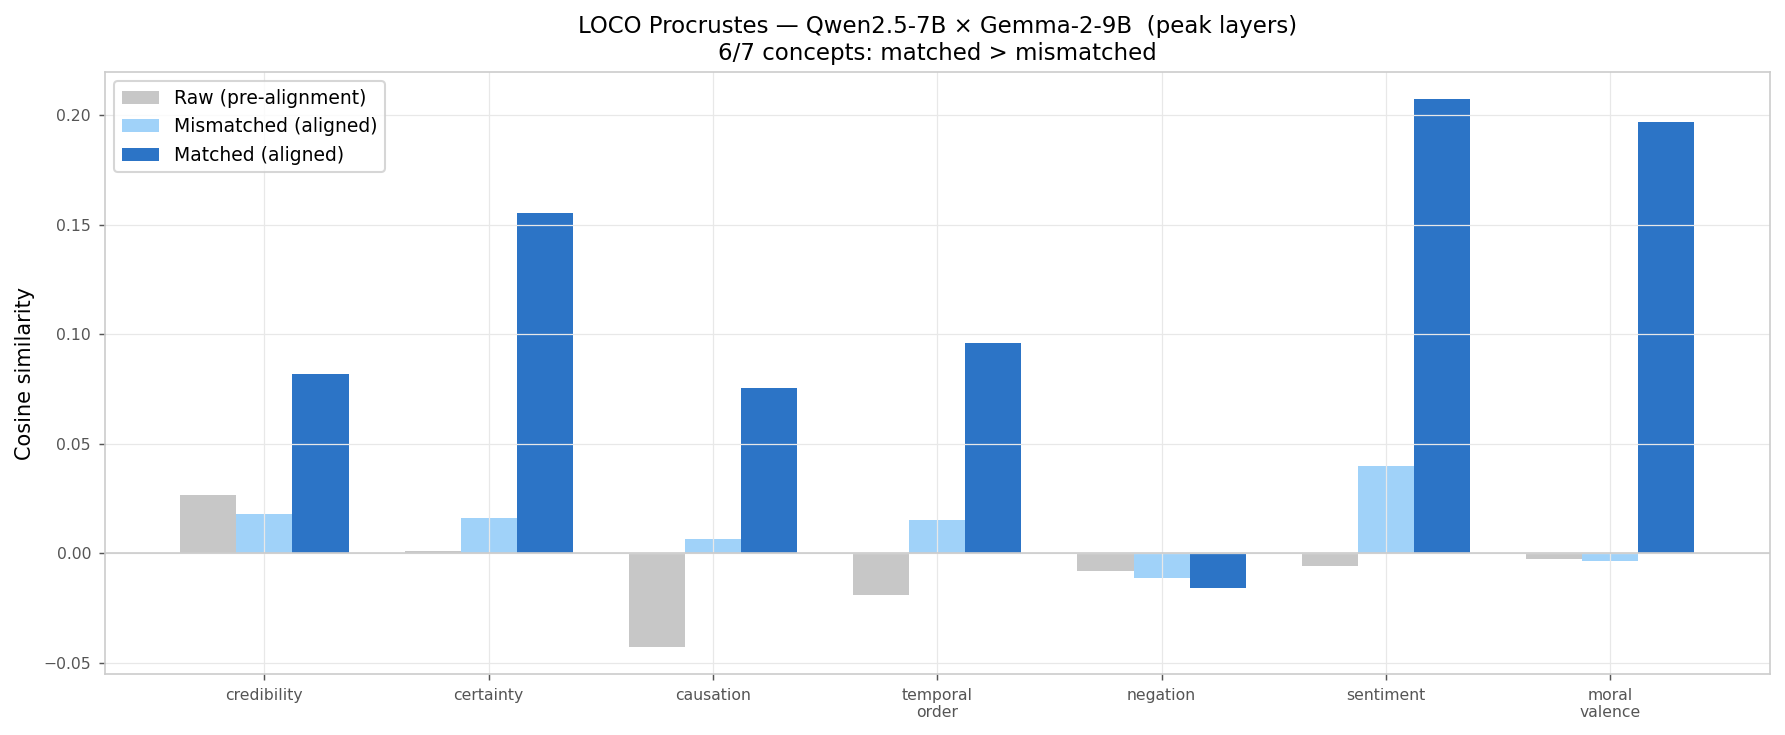

In [10]:
# LOCO Procrustes test — single peak-layer vector per concept
results = []
for held_concept in TEST_CONCEPTS:
    fit_concepts = [c for c in TEST_CONCEPTS if c != held_concept]

    # Calibration: one peak-layer vector per concept  →  shape (6, hidden_dim)
    cal_a = np.vstack([directions["model_a"][c] for c in fit_concepts])
    cal_b = np.vstack([directions["model_b"][c] for c in fit_concepts])

    R = procrustes_rotation(cal_a, cal_b)   # maps model_b → model_a frame

    dir_a = directions["model_a"][held_concept]
    dir_b = directions["model_b"][held_concept]

    raw_cos     = cosine(dir_a, dir_b)
    matched_cos = cosine(dir_a, dir_b @ R)
    mismatch_cosines = [
        cosine(dir_a, directions["model_b"][oc] @ R) for oc in fit_concepts
    ]
    mismatched_mean = float(np.mean(mismatch_cosines))

    results.append({
        "concept":    held_concept,
        "raw":        raw_cos,
        "matched":    matched_cos,
        "mismatched": mismatched_mean,
        "delta":      matched_cos - mismatched_mean,
    })

# Print table
print(f"{'Concept':20s}  {'Raw':>8s}  {'Matched':>9s}  {'Mismatch':>10s}  {'Δ':>7s}")
print("-" * 62)
for r in results:
    sign = "+" if r["delta"] > 0 else " "
    print(f"{r['concept']:20s}  {r['raw']:8.4f}  {r['matched']:9.4f}  "
          f"{r['mismatched']:10.4f}  {sign}{abs(r['delta']):.4f}")
n_pos = sum(1 for r in results if r["delta"] > 0)
print(f"\nPositive Δ: {n_pos}/{len(results)}")

# Bar chart: raw vs mismatched vs matched, per concept
x      = np.arange(len(results))
w      = 0.25
labels = [r["concept"].replace("_", "\n") for r in results]
raw_v  = [r["raw"]        for r in results]
mat_v  = [r["matched"]    for r in results]
mis_v  = [r["mismatched"] for r in results]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.bar(x - w, raw_v, w, label="Raw (pre-alignment)",  color="#BDBDBD", alpha=0.85)
ax.bar(x,     mis_v, w, label="Mismatched (aligned)", color="#90CAF9", alpha=0.85)
ax.bar(x + w, mat_v, w, label="Matched (aligned)",
       color=FAMILY_COLORS.get("Pythia", "#1565C0"), alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Cosine similarity")
ax.set_title(
    f"LOCO Procrustes — Qwen2.5-7B × Gemma-2-9B  (peak layers)\n"
    f"{n_pos}/{len(results)} concepts: matched > mismatched",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.axhline(0, color=THEME["spine"], lw=0.8)
apply_theme(ax)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.patches as mpatches

# ── Concept-space PCA — what Procrustes rotation actually does ─────────────────
# Full-fit on all 7 (for illustration); LOCO above is the rigorous leave-one-out test.
#
# Steps:
#  1. Stack each model's 7 peak-layer directions into a matrix
#  2. Fit Procrustes (procrustes_rotation centres both matrices before finding R)
#  3. PCA on centred Qwen directions → 2-D reference frame
#  4. Project raw Gemma (centred) → small dot-products with Qwen PCA axes → near origin
#  5. Project aligned Gemma (centred → rotated) → coincides with Qwen points

qwen_mat  = np.vstack([directions["model_a"][c] for c in TEST_CONCEPTS])  # (7, 3584)
gemma_mat = np.vstack([directions["model_b"][c] for c in TEST_CONCEPTS])  # (7, 3584)

# np.vstack returns new arrays — in-place centering inside procrustes_rotation is safe
R_full    = procrustes_rotation(qwen_mat, gemma_mat)
# After the call: qwen_mat and gemma_mat are each mean-centred (modified in-place)

# PCA on centred Qwen
_, S, Vt = np.linalg.svd(qwen_mat, full_matrices=False)
comps = Vt[:2]                              # (2, 3584) — top-2 principal directions
evr   = (S[:2]**2) / (S**2).sum()          # fraction of variance explained

q2d = qwen_mat @ comps.T                   # (7, 2) — Qwen projections
g2d = gemma_mat @ comps.T                  # (7, 2) — raw Gemma (centred → small projections)
r2d = (gemma_mat @ R_full) @ comps.T       # (7, 2) — aligned Gemma (≈ Qwen)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.patch.set_facecolor("white")

for ax, panel_title, g_pts in [
    (axes[0], "Before alignment  (raw coordinate frames)", g2d),
    (axes[1], "After Procrustes rotation", r2d),
]:
    for i, concept in enumerate(TEST_CONCEPTS):
        col = concept_color(concept)
        qx, qy = q2d[i]
        gx, gy = g_pts[i]

        # Dashed line — same concept, different model
        ax.plot([qx, gx], [qy, gy], color=col, lw=1.4, ls="--", alpha=0.45, zorder=2)

        # Qwen: filled circle
        ax.scatter(qx, qy, color=col, s=220, zorder=5,
                   marker="o", edgecolors="white", linewidths=1.5)

        # Gemma: open ring — stays visible even when directly on top of Qwen dot
        ax.scatter(gx, gy, facecolors="none", edgecolors=col, s=340,
                   zorder=4, marker="o", linewidths=2.5)

        # Label at Qwen position
        ax.annotate(
            concept.replace("_", " "),
            (qx, qy), textcoords="offset points", xytext=(10, 4),
            fontsize=9, color=col, zorder=6,
        )

    ax.set_title(panel_title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"PC1  ({evr[0]:.0%} of Qwen variance)", fontsize=10)
    ax.set_ylabel(f"PC2  ({evr[1]:.0%} of Qwen variance)", fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.5, alpha=0.3)
    ax.axvline(0, color=THEME["spine"], lw=0.5, alpha=0.3)
    apply_theme(ax)

# Shared legend
leg_q = plt.scatter([], [], color="#555555", s=130, marker="o",
                    edgecolors="white", linewidths=1.5, label="Qwen2.5-7B  (●)")
leg_g = plt.scatter([], [], facecolors="none", edgecolors="#555555", s=200,
                    marker="o", linewidths=2.5, label="Gemma-2-9B  (○)")
fig.legend(handles=[leg_q, leg_g], loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle(
    "Peak-layer concept directions projected into Qwen's 2-D subspace\n"
    "●  Qwen2.5-7B (reference)   ○  Gemma-2-9B   —  dashed lines connect same-concept pairs",
    fontsize=11, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

d_before = np.mean([np.linalg.norm(q2d[i] - g2d[i]) for i in range(len(TEST_CONCEPTS))])
d_after  = np.mean([np.linalg.norm(q2d[i] - r2d[i]) for i in range(len(TEST_CONCEPTS))])
print(f"Mean same-concept pair distance in 2-D: {d_before:.4f}  →  {d_after:.5f}")
print(f"Variance explained: {evr[0]:.1%} + {evr[1]:.1%} = {sum(evr):.1%} of Qwen direction variance")

## 6. Reproduce Paper 4: primary result and depth-stratification

The two-model demo above shows the LOCO protocol on a single cross-family pair. Paper 4 runs this at scale across all same-dimension model pairs in the dataset.

**Primary result (peak-layer, cross-family only):** 33 models, 8 families, 17 concepts, 1,596 cross-family same-dimension pairs. Mean aligned cosine **0.9809** from a raw baseline of 0.0001. The bar chart directly below shows this alongside null distributions.

**Depth-stratification (secondary analysis):** Does matched > mismatched hold at multiple proportional depths — not just the peak layer? This analysis runs on all 563 same-dimension pairs (not cross-family restricted). Mean matched 0.3531 vs mismatched 0.1989, Δ = +0.154, 563/563 positive.

The pre-computed depth-stratification results are in `data/prh_p5_samedim_n250.json`.

In [11]:
# Load pre-computed p5 results
data_path = Path("../data/prh_p5_samedim_n250.json")
if not data_path.exists():
    # Fallback: try current directory (e.g. when running from repo root)
    data_path = Path("data/prh_p5_samedim_n250.json")

with open(data_path) as f:
    p5 = json.load(f)

summary = p5["summary"]["grand"]
pair_results = p5["pair_results"]

print(f"N observations:    {summary['n_observations']}")
print(f"N positive delta:  {summary['n_positive_delta']} / {summary['n_observations']}")
print(f"Mean matched:      {summary['mean_matched']:.4f}")
print(f"Mean mismatched:   {summary['mean_mismatched']:.4f}")
print(f"Mean delta:        {summary['mean_delta']:.4f}")
print(f"Mann-Whitney p:    {summary['mannwhitney_p']:.2e}")
print(f"Bootstrap 95% CI:  [{summary['bootstrap_ci_95'][0]:.4f}, {summary['bootstrap_ci_95'][1]:.4f}]")

N observations:    563
N positive delta:  563 / 563
Mean matched:      0.3531
Mean mismatched:   0.1989
Mean delta:        0.1542
Mann-Whitney p:    4.80e-229
Bootstrap 95% CI:  [0.1466, 0.1619]


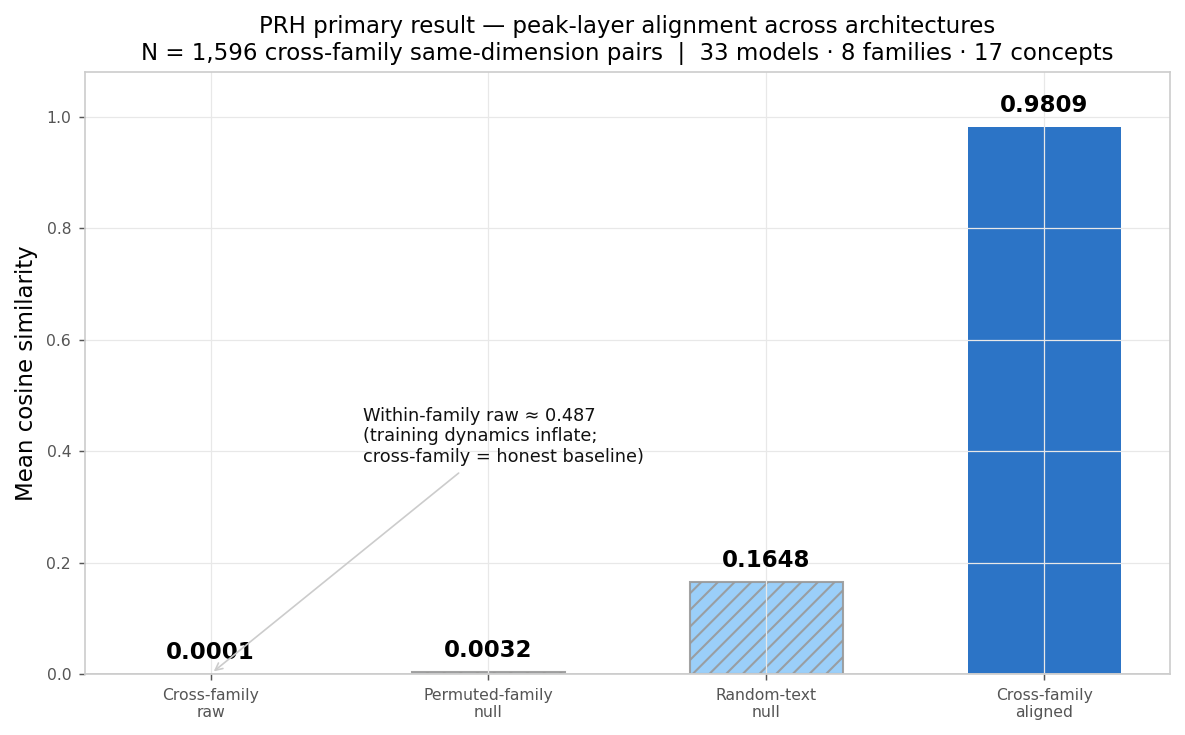

Source: Henry 2026d, §4 — N=1,596 cross-family same-dim pairs, peak-layer LOCO protocol


In [12]:
# ── Primary PRH result — Paper 4 (Henry 2026d) ──────────────────────────────
# Peak-layer LOCO, cross-family pairs only:
#   33 models · 8 families · 17 concepts · 1,596 cross-family same-dimension pairs
#
# Within-family pairs share training dynamics → raw cosine ≈ 0.487 (inflated).
# Cross-family restriction gives an honest near-zero baseline.

PRIMARY = {
    "Cross-family\nraw":        0.0001,
    "Permuted-family\nnull":    0.0032,
    "Random-text\nnull":        0.1648,
    "Cross-family\naligned":    0.9809,
}
_bar_colors = ["#BDBDBD", "#CFD8DC", "#90CAF9", FAMILY_COLORS.get("Pythia", "#1565C0")]
_hatches    = [None, "///", "///", None]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
bars = ax.bar(
    range(len(PRIMARY)), list(PRIMARY.values()),
    color=_bar_colors, alpha=0.9, width=0.55,
)
for bar, hatch in zip(bars, _hatches):
    if hatch:
        bar.set_hatch(hatch)
        bar.set_edgecolor("#999999")
ax.set_xticks(range(len(PRIMARY)))
ax.set_xticklabels(list(PRIMARY.keys()), fontsize=10)
ax.set_ylabel("Mean cosine similarity", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_title(
    "PRH primary result — peak-layer alignment across architectures\n"
    "N = 1,596 cross-family same-dimension pairs  |  33 models · 8 families · 17 concepts",
    fontsize=11,
)
for bar, val in zip(bars, PRIMARY.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.018,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.axhline(0, color=THEME["spine"], lw=0.8)
ax.annotate(
    "Within-family raw ≈ 0.487\n(training dynamics inflate;\ncross-family = honest baseline)",
    xy=(0, 0.0001), xytext=(0.55, 0.38),
    fontsize=8.5, color=THEME["text"],
    arrowprops=dict(arrowstyle="->", color=THEME["spine"], lw=0.8),
)
apply_theme(ax)
plt.tight_layout()
plt.show()
print("Source: Henry 2026d, §4 — N=1,596 cross-family same-dim pairs, peak-layer LOCO protocol")

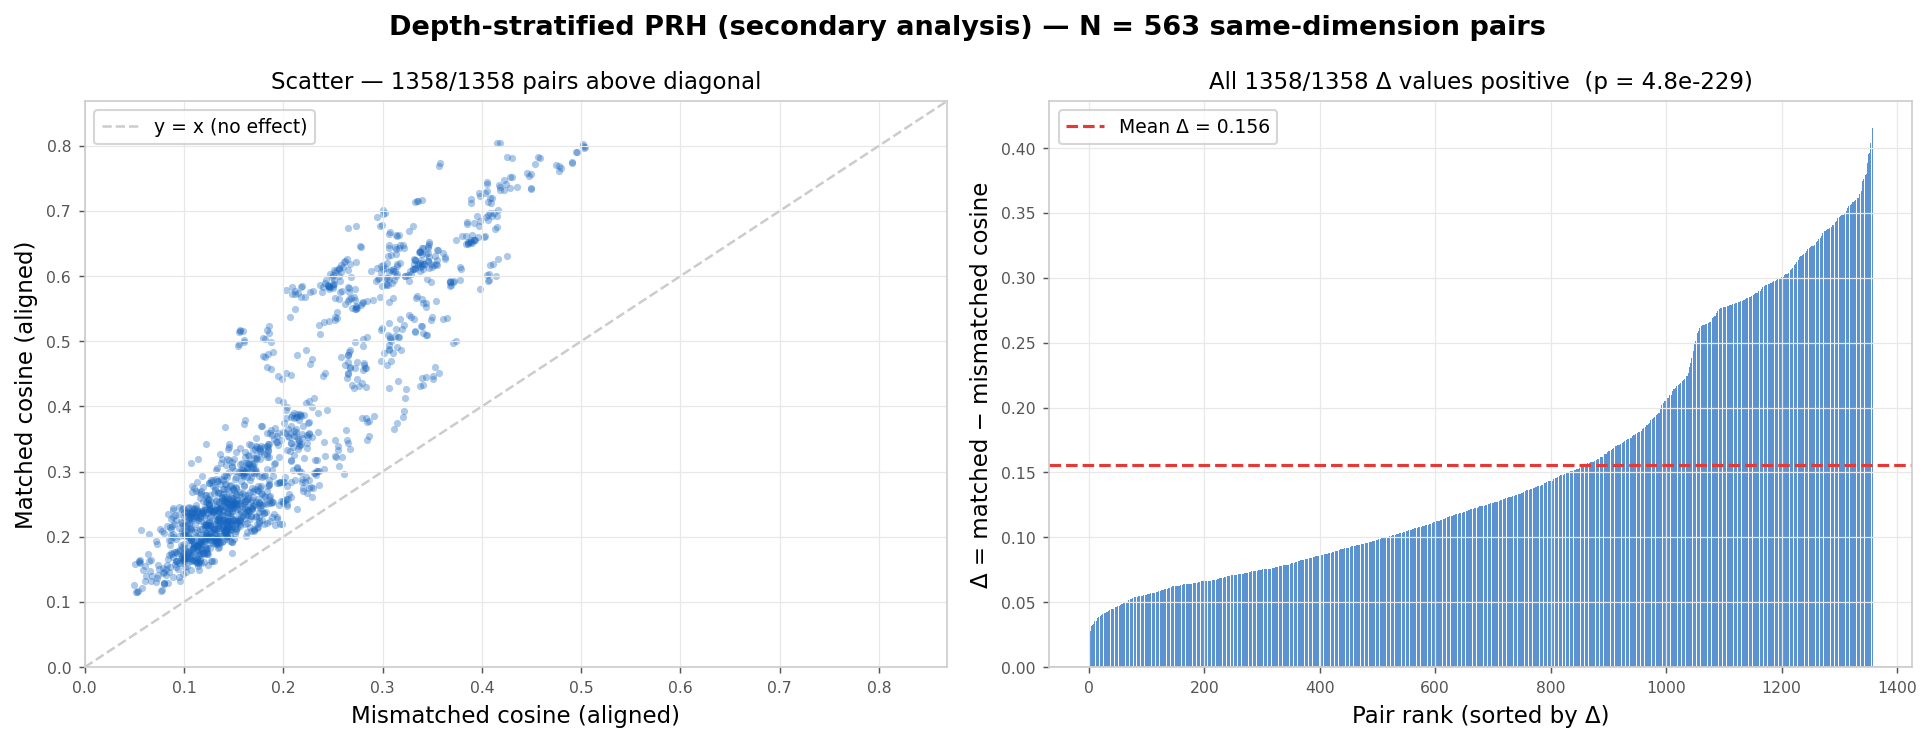

1358/1358 pairs: matched > mismatched  |  mean Δ = 0.1555  |  95% CI [0.1466, 0.1619]


In [13]:
# Depth-stratification: scatter and sorted delta bars across all 563 pairs
matched_means    = [pr["matched_mean"]    for pr in pair_results]
mismatched_means = [pr["mismatched_mean"] for pr in pair_results]
deltas           = sorted([pr["obs_delta"] for pr in pair_results])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Depth-stratified PRH (secondary analysis) — N = 563 same-dimension pairs",
    fontsize=13, fontweight="bold",
)

# Left: scatter matched vs mismatched — all points should be above y = x
ax = axes[0]
lim = max(max(matched_means), max(mismatched_means)) * 1.08
ax.plot([0, lim], [0, lim], color=THEME["spine"], lw=1.2, ls="--", label="y = x (no effect)")
ax.scatter(
    mismatched_means, matched_means,
    alpha=0.35, s=12,
    color=FAMILY_COLORS.get("Pythia", "#1565C0"), linewidths=0,
)
n_above = sum(1 for m, mm in zip(matched_means, mismatched_means) if m > mm)
ax.set_xlabel("Mismatched cosine (aligned)", fontsize=11)
ax.set_ylabel("Matched cosine (aligned)", fontsize=11)
ax.set_title(f"Scatter — {n_above}/{len(matched_means)} pairs above diagonal", fontsize=11)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(fontsize=9)
apply_theme(ax)

# Right: all obs_delta values sorted (all should be positive)
ax = axes[1]
ax.bar(
    range(len(deltas)), deltas,
    color=FAMILY_COLORS.get("Pythia", "#1565C0"), alpha=0.7, linewidth=0,
)
ax.axhline(np.mean(deltas), color="#E53935", lw=1.5, ls="--",
           label=f"Mean Δ = {np.mean(deltas):.3f}")
ax.axhline(0, color=THEME["spine"], lw=0.8)
ax.set_xlabel("Pair rank (sorted by Δ)", fontsize=11)
ax.set_ylabel("Δ = matched − mismatched cosine", fontsize=11)
ax.set_title(
    f"All {len(deltas)}/{len(pair_results)} Δ values positive  "
    f"(p = {summary['mannwhitney_p']:.1e})",
    fontsize=11,
)
ax.legend(fontsize=9)
apply_theme(ax)

plt.tight_layout()
plt.show()
print(
    f"{n_above}/{len(pair_results)} pairs: matched > mismatched  "
    f"|  mean Δ = {np.mean(deltas):.4f}  "
    f"|  95% CI [{summary['bootstrap_ci_95'][0]:.4f}, {summary['bootstrap_ci_95'][1]:.4f}]"
)

## Summary

From first principles to published results:

| Step | What we built |
|------|---------------|
| Fisher separation | Centroid distance normalised by within-class scatter |
| Coherence | Mean cosine similarity to class centroid — directional consistency |
| Velocity | Finite-difference derivative — rate of concept construction |
| Procrustes rotation | SVD-based orthogonal alignment between activation spaces |
| LOCO test | Hold-out evaluation: fit rotation on 6 peak-layer directions, test on the 7th |
| Primary result | 0.0001 → **0.9809** aligned cosine; N = 1,596 cross-family same-dim pairs |
| Depth-stratification | 563/563 model pairs: matched > mismatched at multiple depths; mean Δ = +0.154 |

The primary result says: a single orthogonal rotation maps one architecture's peak-layer concept directions onto another's with 0.9809 mean cosine similarity — starting from a near-zero raw baseline. The same semantic geometry emerges independently across different model families, training pipelines, and scales.

---

| Paper | |
|-------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 4 — Cross-architecture PRH | [Henry 2026d](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |
| Concept pairs dataset | [Rosetta_Concept_Pairs](https://github.com/jamesrahenry/Rosetta_Concept_Pairs) |